In [30]:
import numpy as np
import matplotlib.pyplot as plt

In [27]:
from IPython.display import display, Latex

# Define your LaTeX macros
latex_macros = r"""
\newcommand{\expval}[1]{\langle #1 \rangle}
"""

# Display the macros so that they are available throughout the notebook
display(Latex(f"$${latex_macros}$$"))

<IPython.core.display.Latex object>

# Density Branches

This notebook drafts some approaches to defining a branch factor for quantum states that are really produced in the lab, taking into account noise.

Consider two pure pointer states $|\psi_1\rangle$ and $|\psi_2\rangle$. We aim to produce the state $$\frac{1}{\sqrt{2}}|\psi_1\rangle + \frac{1}{\sqrt{2}}|\psi_2\rangle$$ but what we actually produce in the lab is the density matrix $\rho$.

### Quantum Fidelity

**Definition**: The quantum fidelity $F(|\psi\rangle, \rho)$ between a pure state $|\psi\rangle$ and a density matrix $\rho$ is given by:

$$
F(|\psi\rangle, \rho) = \langle\psi| \rho |\psi\rangle
$$

This fidelity directly represents the probability that a measurement of the state $\rho$ will find it in the state $|\psi\rangle$.

**Lower Bound**: The value of $F(|\psi\rangle, \rho)$ gives a lower bound on the probability that the state $\rho$ corresponds to the pure state $|\psi\rangle$.

In [28]:
# Define the pure states |psi_1, psi_2> (example)
psi_1 = np.array([1, 0, 0, 0])  # Example: |00>
psi_2 = np.array([0, 0, 0, 1])  # Example: |11>
psi = 1/np.sqrt(2)*psi_1 + 1/np.sqrt(2)*psi_2

# Define the noisy density matrix rho (example)
rho = np.array([[0.9, 0.1, 0.1, 0.1],
                [0.1, 0.05, 0.02, 0.02],
                [0.1, 0.02, 0.03, 0.02],
                [0.1, 0.02, 0.02, 0.02]])

# Ensure rho is Hermitian
rho = (rho + rho.T.conj()) / 2

# Calculate fidelity
fidelity = np.vdot(psi, np.dot(rho, psi))

print(f"Fidelity with |psi>: {fidelity}")
print(f"This means there is greater than a {fidelity*100:.2f}% probability that the state psi was prepared")

Fidelity with |psi>: 0.5599999999999998
This means there is greater than a 56.00% probability that the state psi was prepared


### Fidelity of LF Violations
Using this fidelity can give us a probability that we have the intended branch factor. However, in our experiments we need to show that we have both prepared the intended branch factor AND violated local friendliness with those same states. We need to avoid a scenario where it is the incorrect states are the ones dominating the expecation values that contribute to the local friendlieness violation.

Let $p$ be the probability that our target pure state was prepared. This is lower bounded by the fidelity.

Consider a proposed experimental violation of the Semi-Brukner inequality:
$$
X:= -\expval{A_1B_2}+\expval{A_1B_3}-\expval{A_3B_2}-\expval{A_3B_3}\ge 2
$$

To bound the value of $ X $ as a function of the probability $ p $ that the data going into the expectation is valid, we need to consider the worst-case scenario for the expectation values given the bounds and the probability $ 1 - p $ of invalid data.

1. **Expectation Value Bounds:**
   Each expectation value $ \expval{A_i} $ and $ \expval{B_j} $ is bounded between -1 and 1. If there is a probability $ p $ that the data is invalid, the invalid data might skew the expectation values.

2. **Impact of Invalid Data:**
   For invalid data, we assume the worst-case scenario where the invalid data maximizes or minimizes each term in $ X $. Specifically, we consider:
   - The valid data contributes expectation values within the range [-1, 1].
   - The invalid data contributes values that skew the expectation values towards the extremes.

3. **Bounds on $ X $:**
   Given $ p $ is the probability of valid data, the effective expectation value can be modeled as a mixture:
   $$
   \expval{A_i} = p \expval{A_i}^{\text{valid}} + (1-p) \expval{A_i}^{\text{invalid}}
   $$
   Similarly for $ \expval{B_j} $, $ \expval{A_i B_j} $, etc. In the worst-case scenario, the invalid contributions could be at the bounds (-1 or 1).
   Let $\expval{\tilde{A_i}}$ be the measured expectation value. This means that 
$$
   \expval{A_i}^{\text{valid}} = \frac{\expval{\tilde{A_i}} - (1-p) \expval{A_i}^{\text{invalid}}}{p}
$$
We then set $\expval{A_i}^{\text{invalid}}$ to whatever is the worst case for that term in $X$.

#### Worst-Case Analysis
For the positive coefficient: $\expval{A_1 B_3}$ we have 
$$
\begin{align}
   \expval{A_1 B_3}^{\text{valid}} &= \frac{\expval{\tilde{A_1 B_3}} - (1-p) \expval{A_1 B_3}^{\text{invalid}}}{p}\\
   \expval{A_1 B_3}^{\text{valid}} &\ge \frac{\expval{\tilde{A_1 B_3}} - (1-p)*2}{p}
\end{align}
$$

For the negative coefficients we have
$$
\begin{align}
   -\expval{A_i}^{\text{valid}} &= \frac{(1-p) \expval{A_i}^{\text{invalid}}-\expval{\tilde{A_i}}}{p} \\
   -\expval{A_i}^{\text{valid}} &\ge \frac{(1-p)*(-2)-\expval{\tilde{A_i}}}{p} 
   = \frac{2(p-1)-\expval{\tilde{A_i}}}{p}
\end{align}
$$
and similarly for the $B_i$ and $AB$ terms.

This gives 
$$
\begin{align}
X^{\text{valid}}&:= -\expval{A_1B_2}^{\text{valid}}+\expval{A_1B_3}^{\text{valid}}-\expval{A_3B_2}^{\text{valid}}-\expval{A_3B_3}^{\text{valid}} \\
X^{\text{valid}}&\ge 
\frac{1}{p} \left[
2(p-1)-\expval{\tilde{A_1B_2}}
+\expval{\tilde{A_1 B_3}} - (1-p)*2
+2(p-1)-\expval{\tilde{A_3B_2}}
+2(p-1)-\expval{\tilde{A_3B_3}}
\right] \\
X^{\text{valid}}&\ge
\frac{1}{p} \left[
\tilde{X}
+8(p-1)
\right]
\end{align}
$$

It is this value of $X^{\text{valid}}$ that matters to show the violation under noise. We must have:
$$
X^{\text{valid}} \ge 2
$$
or similarly that the measured value
$$
\begin{align}
\tilde{X} &\ge 2p - 8(p-1) \\
\tilde{X} &\ge 8 - 6p
\end{align}
$$

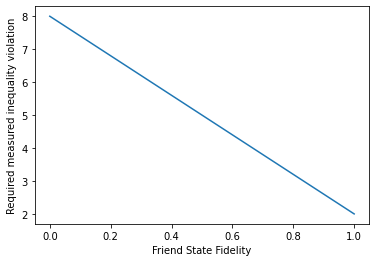

In [42]:
probs = np.linspace(0, 1, 5)
x_tilde = [(8 - 6*p) for p in probs]

plt.xlabel("Friend State Fidelity")
plt.ylabel("Required measured inequality violation")
_ = plt.plot(probs, x_tilde)

## Note that we also will need to adjust the error bars on violations because we will be throwing out samples with probability 1-p. Error bars should come from assuming only p*T samples where T is the number of trials